# NBT theatre statistical analysis

This notebook tests the principal associations identified during exploratory analysis of the NBT theatre dataset. Its purpose is to distinguish descriptive patterns from statistically supported associations and to examine whether theatre-room differences remain after adjustment for procedure and patient characteristics.

The analysis is observational. Statistical significance is therefore not interpreted as causation. Results are reported with sample sizes, effect sizes and 95% confidence intervals where appropriate, in line with transparent reporting guidance for observational research (von Elm *et al*., 2007).

## 1. Prespecified questions and analysis principles

### Primary questions

1. Is recorded operation duration systematically different from planned duration?
2. Does operation duration differ across theatre rooms, procedures, admission pathways, specialties, anaesthetic types, ASA classes and priority levels?
3. Is planned-duration status associated with these operational and clinical categories?
4. Are age and recorded sex associated with operation duration or planned-duration status?
5. Which preoperative factors remain associated with meaningful overrun after simultaneous adjustment?

### Statistical principles

- Continuous theatre durations are strongly right-skewed, so rank-based tests and medians are used for unadjusted comparisons.
- Kruskal-Wallis tests (Kruskal and Wallis, 1952) are followed by pairwise Mann-Whitney tests (Mann and Whitney, 1947) only when the omnibus result supports further comparison. Pairwise p-values are controlled using the Benjamini-Hochberg false-discovery-rate procedure (Benjamini and Hochberg, 1995).
- Categorical associations are assessed using chi-square tests and bias-corrected Cramer's V. Sparse categories are excluded or combined before inference.
- Planned and recorded duration are paired observations. Their agreement is evaluated through their differences and a Bland-Altman plot; correlation alone is not evidence of agreement (Bland and Altman, 1986).
- The multivariable model contains only variables available before or at scheduling. Outcome-derived and postoperative variables are excluded to prevent information leakage.
- A two-sided alpha of 0.05 is used, but conclusions consider effect size, precision, sample size and clinical relevance rather than p-values alone.
- Reconstructed start times and theatre-flow stages remain provisional and are excluded from the primary inferential analysis pending NBT validation.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats
from statsmodels.stats.multitest import multipletests

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT / "src"))

from nbt_pipeline.analysis import (
    categorical_association,
    kruskal_comparison,
    logistic_overrun_model,
    missingness_association,
    spearman_test,
)

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_colwidth", 120)
ALPHA = 0.05
DATA_PATH = PROJECT_ROOT / "result" / "nbt_smallset_analysis_with_features.xlsx"
analysis_df = pd.read_excel(DATA_PATH)
analysis_df.shape

(14918, 66)

In [2]:
integrity_audit = pd.DataFrame({
    "check": [
        "exact_duplicate_rows",
        "nonpositive_recorded_durations",
        "nonpositive_expected_durations",
        "duration_error_identity_failures",
        "overrun_status_flag_mismatches",
        "ages_outside_0_to_125",
    ],
    "count": [
        int(analysis_df.duplicated().sum()),
        int(analysis_df["operation_length_mins"].le(0).sum()),
        int(analysis_df["ExpectedDurationMins"].le(0).sum()),
        int((
            analysis_df["duration_error_mins"]
            - (analysis_df["operation_length_mins"] - analysis_df["ExpectedDurationMins"])
        ).abs().gt(1e-9).sum()),
        int((
            analysis_df["duration_status"].eq("meaningful_overrun")
            != analysis_df["meaningful_overrun_flag"].eq(1)
        ).sum()),
        int((~analysis_df["age_at_operation"].between(0, 125) & analysis_df["age_at_operation"].notna()).sum()),
    ],
})
integrity_audit

,check,count
0,exact_duplicate_rows,7
1,nonpositive_recorded_durations,0
2,nonpositive_expected_durations,0
3,duration_error_identity_failures,0
4,overrun_status_flag_mismatches,0
5,ages_outside_0_to_125,0


**Integrity check.** The derived planning-error identity and meaningful-overrun flag were internally consistent, and no non-positive durations or ages outside the prespecified 0-125 range were detected. Seven rows were exact duplicates across all saved columns. They represent less than 0.05% of the dataset, so they are unlikely to alter the reported estimates materially, but their origin should be checked before the final modelling dataset is frozen. They are retained here to avoid silently changing the saved analysis population.

## 2. Analysis population and outcome integrity

The saved analysis dataset is used without modifying the source file. The primary binary outcome is `meaningful_overrun_flag`, derived from recorded minus expected duration using the project's working tolerance of the greater of 10 minutes or 10% of expected duration. This is a project definition, not an official NBT performance threshold, and must be confirmed with the operational team.

In [3]:
population_summary = pd.DataFrame({
    "measure": [
        "all_rows",
        "recorded_operation_duration_available",
        "expected_duration_available",
        "duration_status_available",
        "meaningful_overrun_cases",
    ],
    "n": [
        len(analysis_df),
        analysis_df["operation_length_mins"].notna().sum(),
        analysis_df["ExpectedDurationMins"].notna().sum(),
        analysis_df["duration_status"].ne("missing_duration").sum(),
        analysis_df["meaningful_overrun_flag"].eq(1).sum(),
    ],
})
population_summary["pct_of_all_rows"] = 100 * population_summary["n"] / len(analysis_df)
population_summary.round(2)

,measure,n,pct_of_all_rows
0,all_rows,14918,100.00
1,recorded_operation_duration_available,14836,99.45
2,expected_duration_available,14642,98.15
3,duration_status_available,14563,97.62
4,meaningful_overrun_cases,4569,30.63


## 3. Planned versus recorded duration

### 3.1 Paired difference test and agreement

The Wilcoxon signed-rank test (Wilcoxon, 1945) examines whether the paired planning-error distribution is centred on zero. Because a statistically significant difference may be operationally small in a large dataset, the median error and Bland-Altman limits of agreement are reported alongside the test.

In [4]:
paired = analysis_df[["ExpectedDurationMins", "operation_length_mins"]].dropna().copy()
paired["difference"] = paired["operation_length_mins"] - paired["ExpectedDurationMins"]
paired["pair_mean"] = paired[["operation_length_mins", "ExpectedDurationMins"]].mean(axis=1)

wilcoxon = stats.wilcoxon(paired["difference"], alternative="two-sided", method="approx")
bias = paired["difference"].mean()
sd_difference = paired["difference"].std(ddof=1)
lower_loa = bias - 1.96 * sd_difference
upper_loa = bias + 1.96 * sd_difference
planning_summary = pd.DataFrame([{
    "n_pairs": len(paired),
    "median_error_mins": paired["difference"].median(),
    "mean_bias_mins": bias,
    "lower_95_limit_of_agreement": lower_loa,
    "upper_95_limit_of_agreement": upper_loa,
    "empirical_2.5th_percentile": paired["difference"].quantile(0.025),
    "empirical_97.5th_percentile": paired["difference"].quantile(0.975),
    "wilcoxon_statistic": wilcoxon.statistic,
    "p_value": wilcoxon.pvalue,
}])
planning_summary.round(3)

,n_pairs,median_error_mins,mean_bias_mins,lower_95_limit_of_agreement,upper_95_limit_of_agreement,empirical_2.5th_percentile,empirical_97.5th_percentile,wilcoxon_statistic,p_value
0,14563,-8.0,-0.491,-134.281,133.299,-107.0,152.0,44780094.0,0.0


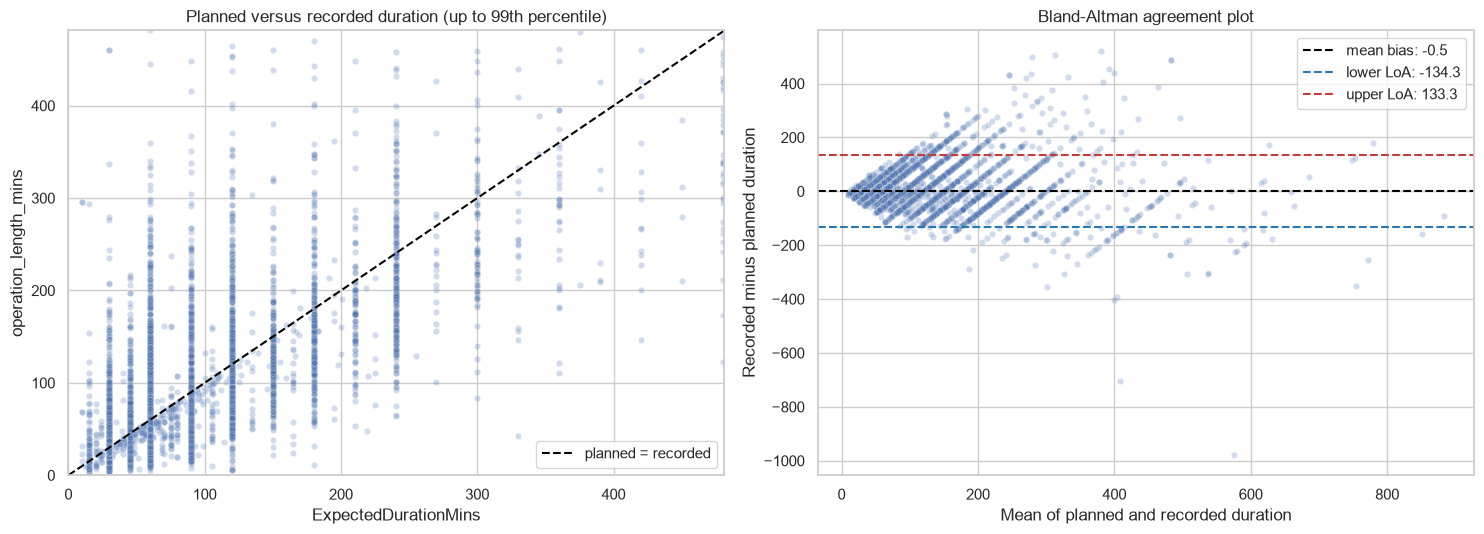

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))
sns.scatterplot(
    data=paired.sample(min(6000, len(paired)), random_state=42),
    x="ExpectedDurationMins", y="operation_length_mins", alpha=0.25, s=20, ax=axes[0]
)
limit = max(paired["ExpectedDurationMins"].quantile(.99), paired["operation_length_mins"].quantile(.99))
axes[0].plot([0, limit], [0, limit], "--", color="black", label="planned = recorded")
axes[0].set(xlim=(0, limit), ylim=(0, limit), title="Planned versus recorded duration (up to 99th percentile)")
axes[0].legend()

sns.scatterplot(
    data=paired.sample(min(6000, len(paired)), random_state=42),
    x="pair_mean", y="difference", alpha=0.25, s=20, ax=axes[1]
)
for value, label, colour in [(bias, "mean bias", "black"), (lower_loa, "lower LoA", "#2878B5"), (upper_loa, "upper LoA", "#C43C39")]:
    axes[1].axhline(value, linestyle="--", color=colour, label=f"{label}: {value:.1f}")
axes[1].set(title="Bland-Altman agreement plot", xlabel="Mean of planned and recorded duration", ylabel="Recorded minus planned duration")
axes[1].legend()
plt.tight_layout()

**Interpretation.** Among 14,563 complete pairs, the median planning error was -8 minutes, meaning that the typical recorded duration was slightly shorter than booked. The Wilcoxon test was significant (`p < 0.0001`), but this is not evidence of a large operational effect: with this sample size, even a small systematic difference is detectable. The mean error was close to zero (-0.49 minutes), while the conventional 95% limits of agreement were approximately -134 to +133 minutes. Thus, positive and negative errors broadly cancel at aggregate level, although agreement for an individual case can be poor.

The error distribution is skewed and contains extreme values, so the normal-theory Bland-Altman limits are treated as descriptive rather than exact probability limits; empirical 2.5th and 97.5th percentiles are also reported. The principal finding is that a small average bias coexists with substantial case-level uncertainty. Extreme differences should be investigated against procedure and source records, not removed automatically.

## 4. Operation-duration differences across groups

Kruskal-Wallis tests evaluate whether the distributions of recorded operation length differ across the main operational and clinical categories. Epsilon-squared summarises the magnitude of each omnibus association. Categories with fewer than 20 observations are not tested because unstable small groups can produce misleading comparisons.

In [6]:
duration_factors = [
    "TheatreRoom",
    "procedure_code_category",
    "admission_type_label",
    "intended_management_label",
    "session_specialty",
    "anaesthetic_desc",
    "ASAScore",
    "PriorityLevelCode",
]

duration_omnibus = []
duration_posthoc = {}
for factor in duration_factors:
    omnibus, pairwise = kruskal_comparison(
        analysis_df, factor, "operation_length_mins", min_group_size=20
    )
    if not omnibus.empty:
        duration_omnibus.append(omnibus)
        duration_posthoc[factor] = pairwise

duration_test_results = pd.concat(duration_omnibus, ignore_index=True)
duration_test_results["p_fdr_bh"] = multipletests(
    duration_test_results["p_value"], method="fdr_bh"
)[1]
duration_test_results.sort_values("epsilon_squared", ascending=False).round(4)

,category,outcome,groups,n,kruskal_h,p_value,epsilon_squared,p_fdr_bh
1,procedure_code_category,operation_length_mins,145,12329,7919.1219,0.0,0.6381,0.0
0,TheatreRoom,operation_length_mins,41,14806,4644.0134,0.0,0.3118,0.0
5,anaesthetic_desc,operation_length_mins,7,14099,4197.6666,0.0,0.2975,0.0
3,intended_management_label,operation_length_mins,4,14825,3593.1922,0.0,0.2422,0.0
4,session_specialty,operation_length_mins,19,14155,2747.8400,0.0,0.1931,0.0
6,ASAScore,operation_length_mins,6,13595,1555.9250,0.0,0.1141,0.0
2,admission_type_label,operation_length_mins,11,14796,614.4373,0.0,0.0409,0.0
7,PriorityLevelCode,operation_length_mins,3,6344,101.3647,0.0,0.0157,0.0


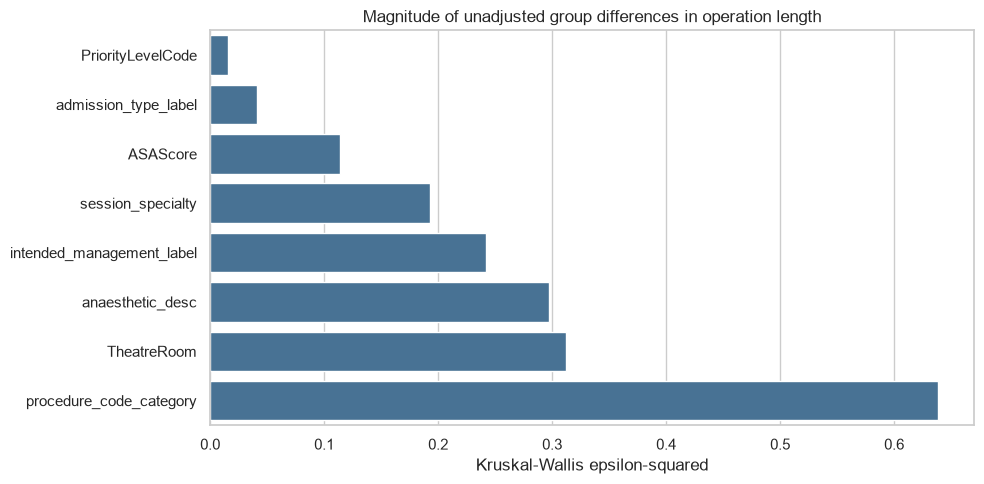

In [7]:
plot_data = duration_test_results.sort_values("epsilon_squared")
plt.figure(figsize=(10, 5))
sns.barplot(data=plot_data, x="epsilon_squared", y="category", color="#3B73A1")
plt.title("Magnitude of unadjusted group differences in operation length")
plt.xlabel("Kruskal-Wallis epsilon-squared")
plt.ylabel("")
plt.tight_layout()

**Interpretation.** All eight omnibus tests were statistically significant after false-discovery-rate correction, but their magnitudes differed substantially. Procedure category showed the strongest unadjusted separation in operation length (epsilon-squared = 0.638), followed by theatre room (0.312), anaesthetic type (0.298), intended management (0.242) and specialty (0.193). ASA showed a smaller association (0.114), while admission type (0.041) and priority (0.016) separated operation-length ranks only weakly.

These effect sizes describe unadjusted rank separation; they are not percentages of duration causally explained. The results indicate that procedure and operational allocation are much more informative about duration than priority alone. Room differences cannot be interpreted as room performance because rooms receive different procedures, pathways and case mixes. Pairwise Mann-Whitney results are retained for targeted follow-up, with Benjamini-Hochberg correction, rather than used to rank every category indiscriminately.

## 5. Duration-status associations

Chi-square tests assess whether the proportions of meaningful overrun, within-tolerance and meaningful underrun differ across categories. Bias-corrected Cramer's V is reported because it describes association strength independently of sample size. Expected-cell diagnostics are retained; a result with many expected counts below five should not be relied upon without category consolidation or an exact/Monte Carlo alternative.

In [8]:
status_factors = duration_factors + ["sex_national_code"]
status_rows = []
status_tables = {}
classified = analysis_df[analysis_df["duration_status"].isin([
    "meaningful_overrun", "within_tolerance", "meaningful_underrun"
])]

for factor in status_factors:
    result, table = categorical_association(classified, factor, min_group_size=20)
    if not result.empty:
        status_rows.append(result)
        status_tables[factor] = table

status_test_results = pd.concat(status_rows, ignore_index=True)
status_test_results["p_fdr_bh"] = multipletests(
    status_test_results["p_value"], method="fdr_bh"
)[1]
status_test_results.sort_values("cramers_v_corrected", ascending=False).round(4)

,category,outcome,n,chi_square,degrees_of_freedom,p_value,cramers_v_corrected,minimum_expected_count,cells_expected_below_5_pct,p_fdr_bh
1,procedure_code_category,duration_status,12055,5868.5361,286,0.0000,0.4812,4.7632,0.9259,0.0000
0,TheatreRoom,duration_status,14537,4893.0908,80,0.0000,0.4069,31.3982,0.0000,0.0000
4,session_specialty,duration_status,13893,2663.1803,36,0.0000,0.3075,4.6570,1.7544,0.0000
2,admission_type_label,duration_status,14524,2741.0561,20,0.0000,0.3061,7.6911,0.0000,0.0000
3,intended_management_label,duration_status,14552,2114.3665,6,0.0000,0.2692,7.2132,0.0000,0.0000
5,anaesthetic_desc,duration_status,13890,1169.7483,12,0.0000,0.2042,29.8934,0.0000,0.0000
6,ASAScore,duration_status,13314,605.8761,8,0.0000,0.1499,7.5870,0.0000,0.0000
8,sex_national_code,duration_status,14517,10.8078,2,0.0045,0.0246,1614.5237,0.0000,0.0051
7,PriorityLevelCode,duration_status,6328,5.2057,4,0.2668,0.0098,167.1884,0.0000,0.2668


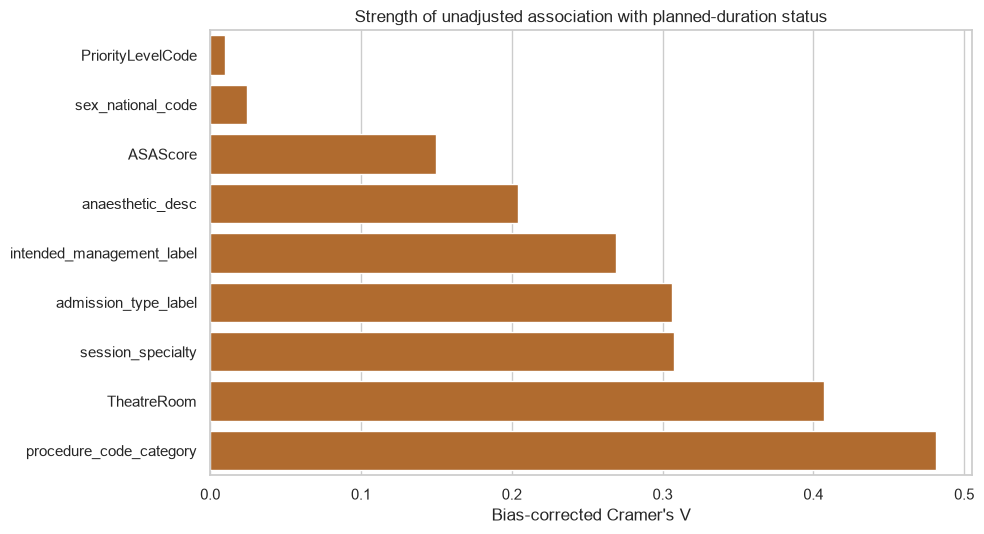

In [9]:
plot_data = status_test_results.sort_values("cramers_v_corrected")
plt.figure(figsize=(10, 5.5))
sns.barplot(data=plot_data, x="cramers_v_corrected", y="category", color="#C56A1A")
plt.title("Strength of unadjusted association with planned-duration status")
plt.xlabel("Bias-corrected Cramer's V")
plt.ylabel("")
plt.tight_layout()

**Interpretation.** Planned-duration status was most strongly associated with procedure category (corrected Cramer's V = 0.481) and theatre room (0.407). Specialty (0.308), admission pathway (0.306) and intended management (0.269) also showed material unadjusted differences, followed by anaesthetic type (0.204) and ASA (0.150). Recorded sex was statistically associated with status but the effect was negligible (V = 0.025). Priority was not significant after correction (`p = 0.267`, V = 0.010).

The expected-count diagnostics were acceptable for the principal tables, although sparse tail categories still require caution. These findings identify where status composition differs; they do not show that a room or procedure causes overrun. Procedure allocation and case mix overlap strongly with room, specialty and anaesthetic type, which motivates the adjusted model in Section 8.

## 6. Age and recorded sex

Age is retained as a continuous variable for primary testing to avoid information loss from arbitrary bands. Spearman correlation (Spearman, 1904) evaluates monotonic relationships with recorded operation length and planning error. Age-group comparisons are provided as a secondary descriptive analysis. Recorded sex is tested against operation length and duration status; these analyses describe association and do not explain mechanisms.

In [10]:
age_results = pd.concat([
    spearman_test(analysis_df, "age_at_operation", "operation_length_mins"),
    spearman_test(analysis_df, "age_at_operation", "duration_error_mins"),
], ignore_index=True)
age_results["p_fdr_bh"] = multipletests(age_results["p_value"], method="fdr_bh")[1]
age_results.round(4)

,variable_1,variable_2,n,spearman_rho,p_value,p_fdr_bh
0,age_at_operation,operation_length_mins,14790,-0.0368,0.0,0.0
1,age_at_operation,duration_error_mins,14517,-0.0876,0.0,0.0


In [11]:
age_data = analysis_df.copy()
age_data["age_group"] = pd.cut(
    age_data["age_at_operation"],
    bins=[-np.inf, 17, 34, 49, 64, 79, np.inf],
    labels=["0-17", "18-34", "35-49", "50-64", "65-79", "80+"],
)
age_duration_test, age_duration_pairs = kruskal_comparison(
    age_data, "age_group", "operation_length_mins", min_group_size=20
)
age_status_test, age_status_table = categorical_association(
    age_data[age_data["duration_status"].ne("missing_duration")],
    "age_group", min_group_size=20
)
pd.concat([age_duration_test, age_status_test], ignore_index=True, sort=False).round(4)

,category,outcome,groups,n,kruskal_h,p_value,epsilon_squared,chi_square,degrees_of_freedom,cramers_v_corrected,minimum_expected_count,cells_expected_below_5_pct
0,age_group,operation_length_mins,6.0,14790,68.0924,0.0,0.0043,NaN,NaN,NaN,NaN,NaN
1,age_group,duration_status,NaN,14517,NaN,0.0,NaN,200.9737,10.0,0.0811,23.3313,0.0


In [12]:
sex_data = analysis_df[analysis_df["sex_national_code"].isin([1, 2])].copy()
sex_groups = [
    group["operation_length_mins"].dropna().to_numpy()
    for _, group in sex_data.groupby("sex_national_code")
]
sex_u = stats.mannwhitneyu(*sex_groups, alternative="two-sided")
sex_status_result, sex_status_table = categorical_association(
    sex_data[sex_data["duration_status"].ne("missing_duration")],
    "sex_national_code", min_group_size=20
)
pd.DataFrame([{
    "duration_mann_whitney_u": sex_u.statistic,
    "duration_p_value": sex_u.pvalue,
    "median_code_1": np.median(sex_groups[0]),
    "median_code_2": np.median(sex_groups[1]),
    "status_chi_square": sex_status_result["chi_square"].iloc[0],
    "status_p_value": sex_status_result["p_value"].iloc[0],
    "status_cramers_v": sex_status_result["cramers_v_corrected"].iloc[0],
}]).round(4)

,duration_mann_whitney_u,duration_p_value,median_code_1,median_code_2,status_chi_square,status_p_value,status_cramers_v
0,28311008.0,0.0001,71.0,69.0,10.8078,0.0045,0.0246


**Interpretation.** Age had a negligible monotonic relationship with operation length (Spearman rho = -0.037) and only a very weak negative relationship with planning error (rho = -0.088); both p-values were small because the sample was large. Age groups likewise explained little separation in duration ranks (epsilon-squared = 0.004) and had only a weak association with duration status (Cramer's V = 0.081). The descriptive tendency toward more underruns at older ages is therefore small and may reflect procedure, planned duration, ASA and pathway mix.

Recorded sex codes 1 and 2 had median operation lengths of 71 and 69 minutes. Their Mann-Whitney comparison was statistically significant (`p = 0.0001`), but the two-minute median difference and status association (V = 0.025) are too small to support an operational conclusion. Neither age nor recorded sex should be treated as a major bottleneck driver from these unadjusted results.

## 7. Missingness analysis

Missing data can be informative. This section checks whether absence of priority, ASA or key scheduling fields is associated with meaningful overrun. A significant result does not reveal why the value is missing; it indicates that complete-case analysis could select a systematically different subset.

In [13]:
missingness_columns = [
    "PriorityLevelCode",
    "ASAScore",
    "admission_type_label",
    "anaesthetic_desc",
    "session_specialty",
    "procedure_code_category",
]
missingness_results = pd.concat(
    [missingness_association(analysis_df, column) for column in missingness_columns],
    ignore_index=True,
)
missingness_results["p_fdr_bh"] = multipletests(
    missingness_results["p_value"], method="fdr_bh"
)[1]
missingness_results.round(4)

,column,n,missing_n,overrun_rate_present,overrun_rate_missing,chi_square,p_value,p_fdr_bh
0,PriorityLevelCode,14563,8234,0.1499,0.4396,1393.4831,0.0000,0.000
1,ASAScore,14563,1232,0.3124,0.3287,1.3302,0.2488,0.311
2,admission_type_label,14563,2,0.3138,0.0000,0.0377,0.8460,0.846
3,anaesthetic_desc,14563,673,0.3046,0.5022,115.5166,0.0000,0.000
4,procedure_code_category,14563,76,0.3151,0.0526,22.9882,0.0000,0.000


**Interpretation.** Missingness was not random with respect to the outcome for several fields. Meaningful-overrun prevalence was 44.0% when priority was missing versus 15.0% when recorded, and 50.2% when anaesthetic type was missing versus 30.5% when recorded (`p < 0.0001` for both). ASA missingness showed no clear association (32.9% versus 31.2%, `p = 0.249`). Procedure-category missingness was associated with a much lower observed overrun prevalence (5.3% versus 31.5%), but only 76 records were missing, so this estimate is imprecise and may reflect a specific workflow.

These tests do not show that missing data cause overruns. They show that silently restricting analysis to complete records could change the analysed case mix. Explicit missing categories are therefore retained in adjusted categorical predictors. This preserves observations and makes missingness visible, but it is not a substitute for investigating why fields are absent or for a formal missing-data sensitivity analysis.

## 8. Adjusted meaningful-overrun model

A multivariable logistic regression estimates the association between preoperative factors and meaningful overrun while holding the other included variables constant. The model includes log expected duration, age, theatre room, three-character OPCS category, admission pathway, ASA, priority, anaesthetic type and specialty. Rare categorical levels are grouped as `Other`; missing categorical values are represented explicitly.

The following outcome-derived variables are deliberately excluded: recorded operation length, duration error, overrun/underrun minutes, duration status and all postoperative flow variables. Including them would leak the answer into the predictors. Consultant/session labels are also excluded from the primary model because they are not validated individual identifiers and are strongly confounded with room and procedure allocation.

In [14]:
overrun_model, adjusted_or, model_data = logistic_overrun_model(analysis_df)
model_summary = pd.DataFrame([{
    "n_modelled": int(overrun_model.nobs),
    "meaningful_overruns": int(model_data["meaningful_overrun_flag"].sum()),
    "parameters": int(overrun_model.df_model + 1),
    "aic": overrun_model.aic,
    "deviance": overrun_model.deviance,
    "null_deviance": overrun_model.null_deviance,
    "mcfadden_pseudo_r2": 1 - overrun_model.llf / overrun_model.llnull,
}])
model_summary.round(2)

C:\Users\Alaa\final_project\src\nbt_pipeline\analysis\statistics.py:192: RuntimeWarning: overflow encountered in exp
  "ci_95_upper": np.exp(confidence[1].values),


,n_modelled,meaningful_overruns,parameters,aic,deviance,null_deviance,mcfadden_pseudo_r2
0,14563,4569,111,12951.27,12729.27,18118.14,0.3


In [15]:
categorical_model_columns = [
    "TheatreRoom", "procedure_code_category", "admission_type_label",
    "ASAScore", "PriorityLevelCode", "anaesthetic_desc", "session_specialty",
]
reference_categories = pd.DataFrame({
    "predictor": categorical_model_columns,
    "reference_category": [
        sorted(model_data[column].astype(str).unique())[0]
        for column in categorical_model_columns
    ],
})
reference_categories

,predictor,reference_category
0,TheatreRoom,BRUNEL TH 01
1,procedure_code_category,A57
2,admission_type_label,Missing
3,ASAScore,1.0
4,PriorityLevelCode,Missing
5,anaesthetic_desc,GA
6,session_specialty,Breast


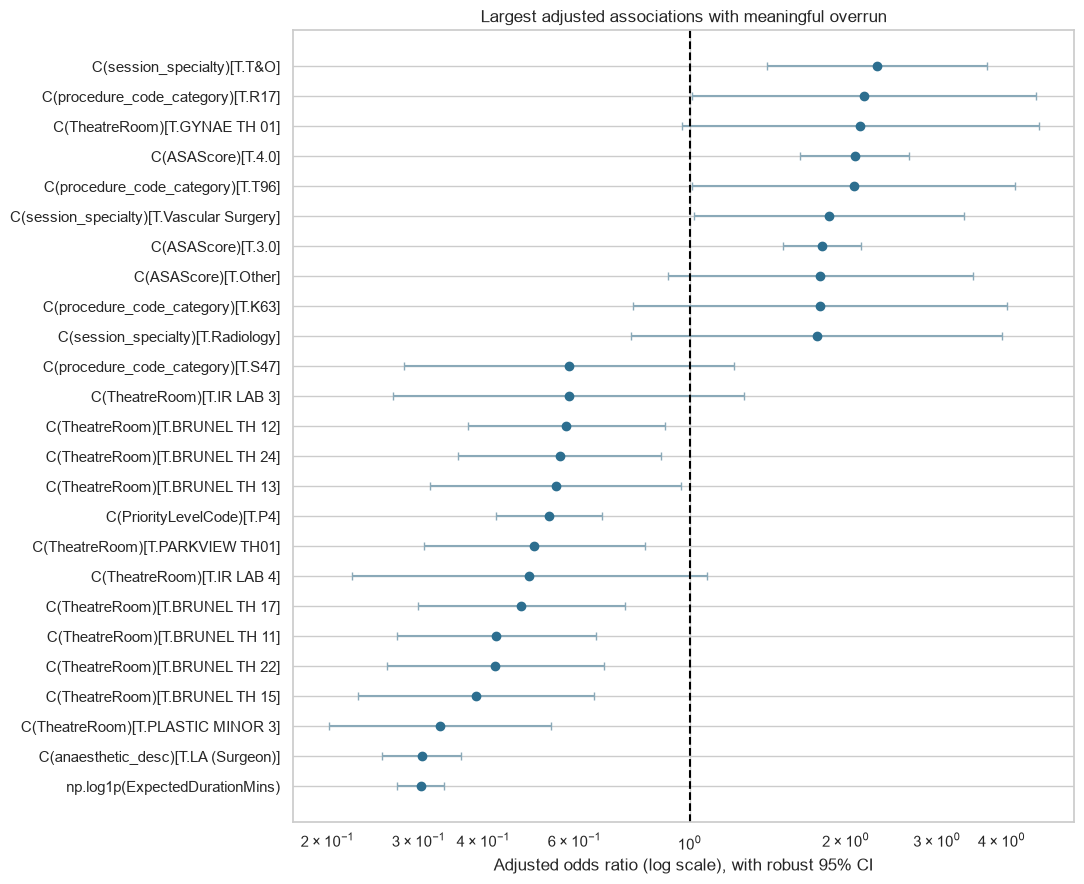

In [16]:
display_terms = adjusted_or[
    adjusted_or["term"].ne("Intercept")
    & adjusted_or["ci_95_lower"].gt(0.20)
    & adjusted_or["ci_95_upper"].lt(5.00)
].copy()
display_terms["distance_from_null"] = abs(np.log(display_terms["odds_ratio"]))
display_terms = display_terms.nlargest(25, "distance_from_null").sort_values("odds_ratio")

plt.figure(figsize=(11, 9))
plt.errorbar(
    display_terms["odds_ratio"], display_terms["term"],
    xerr=[
        display_terms["odds_ratio"] - display_terms["ci_95_lower"],
        display_terms["ci_95_upper"] - display_terms["odds_ratio"],
    ],
    fmt="o", color="#2C6E8F", ecolor="#8AA9B8", capsize=3,
)
plt.axvline(1, color="black", linestyle="--")
plt.xscale("log")
plt.xlabel("Adjusted odds ratio (log scale), with robust 95% CI")
plt.ylabel("")
plt.title("Largest adjusted associations with meaningful overrun")
plt.tight_layout()

In [17]:
adjusted_or.sort_values("p_fdr_bh").head(30).round(4)

,term,odds_ratio,ci_95_lower,ci_95_upper,p_value,p_fdr_bh,reject_fdr_0_05
0,Intercept,0.0000,NaN,NaN,NaN,NaN,False
1,C(TheatreRoom)[T.BRUNEL TH 02],1.1040,0.7648,1.5938,0.5973,NaN,False
2,C(TheatreRoom)[T.BRUNEL TH 03],1.5164,0.9908,2.3210,0.0552,NaN,False
3,C(TheatreRoom)[T.BRUNEL TH 04],1.1220,0.7302,1.7241,0.5995,NaN,False
4,C(TheatreRoom)[T.BRUNEL TH 05],0.3188,0.1085,0.9362,0.0375,NaN,False
5,C(TheatreRoom)[T.BRUNEL TH 06],0.2828,0.0853,0.9372,0.0388,NaN,False
6,C(TheatreRoom)[T.BRUNEL TH 07],1.3855,0.8554,2.2442,0.1851,NaN,False
7,C(TheatreRoom)[T.BRUNEL TH 08],0.6564,0.4167,1.0341,0.0694,NaN,False
8,C(TheatreRoom)[T.BRUNEL TH 09],0.8346,0.5513,1.2635,0.3928,NaN,False
9,C(TheatreRoom)[T.BRUNEL TH 10],1.2637,0.6649,2.4017,0.4751,NaN,False


**Interpretation.** The model included 14,563 cases and 4,569 meaningful overruns. McFadden's pseudo-R-squared was approximately 0.296, indicating that the included scheduling and case-mix variables improve fit materially over an intercept-only model; it is not directly comparable with ordinary least-squares R-squared and does not establish predictive validity. Odds ratios for categorical variables are read relative to the reference categories displayed above. Confidence intervals crossing one do not provide clear adjusted evidence.

Age was not independently associated with meaningful overrun after adjustment (OR 1.001 per year, 95% CI 0.998-1.003; FDR-adjusted `p = 0.706`). BRUNEL TH 03 had an adjusted OR of 1.49 relative to BRUNEL TH 01, but its confidence interval crossed one (0.97-2.27; FDR-adjusted `p = 0.113`); this analysis therefore does not confirm an independent BRUNEL TH 03 effect.

The coefficient for `log1p(ExpectedDurationMins)` must be interpreted especially cautiously. Its OR of 0.304 is for a one-unit increase on the log scale, not one extra booked minute. More importantly, expected duration is mathematically involved in both the planning error and the project's tolerance-based outcome definition. Its strong association is therefore partly structural and should not be presented as evidence that longer bookings themselves prevent overruns.

The model reduces measured confounding compared with separate charts, but it remains associational. HC3 robust confidence intervals address variance misspecification, not correlation among repeated cases within organisational units. Residual confounding, coding quality, sparse levels, the unvalidated consultant labels and the provisional overrun definition remain limitations. Room coefficients are not performance scores; a validated hierarchy would require multilevel or clustered modelling and external validation.

### 8.1 Theatre-room by procedure-group interaction screening

An interaction asks whether the association between procedure group and meaningful overrun changes across theatre rooms. The descriptive room-by-procedure heatmaps are already presented in the EDA notebook (Section 10.8.1.1). This section adds a formal, deliberately restricted screening analysis.

A full interaction containing every room and procedure group is not estimable reliably: the allocation table contains 45 rooms and 145 procedure groups, but most combinations are structural zeros. A procedure group is therefore screened only when it has at least 30 classified cases in each of at least three rooms. Within each eligible procedure group, a chi-square test compares meaningful-overrun prevalence across rooms. Bias-corrected Cramer's V describes the magnitude of the within-procedure room association, and Benjamini-Hochberg correction controls the false-discovery rate across screened procedure groups.

In [18]:
from scipy import stats

interaction_source = analysis_df[
    analysis_df["meaningful_overrun_flag"].notna()
    & analysis_df["TheatreRoom"].notna()
    & analysis_df["procedure_code_group"].notna()
].copy()

interaction_rows = []
interaction_rate_rows = []
for procedure_group, group in interaction_source.groupby("procedure_code_group"):
    room_counts = group["TheatreRoom"].value_counts()
    eligible_rooms = room_counts[room_counts >= 30].index
    screened = group[group["TheatreRoom"].isin(eligible_rooms)].copy()
    table = pd.crosstab(screened["TheatreRoom"], screened["meaningful_overrun_flag"])
    if table.shape[0] < 3 or table.shape[1] < 2:
        continue

    chi_square, p_value, degrees_of_freedom, expected = stats.chi2_contingency(table)
    n = int(table.to_numpy().sum())
    rows, columns = table.shape
    phi_squared = chi_square / n
    phi_corrected = max(
        0.0,
        phi_squared - ((columns - 1) * (rows - 1)) / (n - 1),
    )
    rows_corrected = rows - ((rows - 1) ** 2) / (n - 1)
    columns_corrected = columns - ((columns - 1) ** 2) / (n - 1)
    denominator = min(rows_corrected - 1, columns_corrected - 1)
    cramers_v = np.sqrt(phi_corrected / denominator) if denominator > 0 else np.nan

    rates = screened.groupby("TheatreRoom")["meaningful_overrun_flag"].agg(
        cases="size", overrun_rate="mean"
    ).reset_index()
    rates["procedure_code_group"] = procedure_group
    interaction_rate_rows.append(rates)
    interaction_rows.append({
        "procedure_code_group": procedure_group,
        "eligible_rooms": len(eligible_rooms),
        "n": n,
        "chi_square": chi_square,
        "degrees_of_freedom": degrees_of_freedom,
        "p_value": p_value,
        "cramers_v_corrected": cramers_v,
        "minimum_expected_count": expected.min(),
        "minimum_room_overrun_rate": rates["overrun_rate"].min(),
        "maximum_room_overrun_rate": rates["overrun_rate"].max(),
        "lowest_rate_room": rates.loc[rates["overrun_rate"].idxmin(), "TheatreRoom"],
        "highest_rate_room": rates.loc[rates["overrun_rate"].idxmax(), "TheatreRoom"],
    })

room_procedure_interaction = pd.DataFrame(interaction_rows)
interaction_rates = pd.concat(interaction_rate_rows, ignore_index=True)
room_procedure_interaction["p_fdr_bh"] = multipletests(
    room_procedure_interaction["p_value"], method="fdr_bh"
)[1]
room_procedure_interaction["reject_fdr_0_05"] = (
    room_procedure_interaction["p_fdr_bh"] < ALPHA
)
room_procedure_interaction.sort_values(
    "cramers_v_corrected", ascending=False
).round(4)

,procedure_code_group,eligible_rooms,n,chi_square,degrees_of_freedom,p_value,cramers_v_corrected,minimum_expected_count,minimum_room_overrun_rate,maximum_room_overrun_rate,lowest_rate_room,highest_rate_room,p_fdr_bh,reject_fdr_0_05
7,V2,4,175,69.7144,3,0.0000,0.6191,12.4000,0.0789,0.8333,BRUNEL TH 19,BRUNEL TH 06,0.0000,True
6,S5,5,324,30.1936,4,0.0000,0.2847,12.1728,0.3469,0.9118,PLASTIC MINOR 3,BRUNEL TH 03,0.0000,True
1,M1,3,300,12.8363,2,0.0016,0.1903,5.1000,0.0708,0.2222,IR LAB 2,IR LAB 1,0.0037,True
2,M3,3,130,4.7314,2,0.0939,0.1451,2.4923,0.0192,0.1389,BRUNEL TH 15,BRUNEL TH 13,0.1056,False
4,S0,6,1306,30.2932,5,0.0000,0.1392,0.8040,0.0068,0.1064,PLASTIC MINOR 1,BRUNEL TH 12,0.0000,True
0,L7,3,303,7.3163,2,0.0258,0.1326,14.4554,0.4274,0.6333,IR LAB 2,HYBRID THEATRE,0.0464,True
5,S4,3,121,3.9363,2,0.1397,0.1265,8.6777,0.1562,0.3667,PLASTIC MINOR 3,BRUNEL TH 02,0.1397,False
3,M4,3,348,6.6002,2,0.0369,0.1151,5.6897,0.0823,0.2000,BRUNEL TH 15,PARKVIEW TH02,0.0553,False
8,W2,3,320,5.1844,2,0.0749,0.0998,9.6875,0.7000,0.8447,BRUNEL TH 02,BRUNEL TH 03,0.0962,False


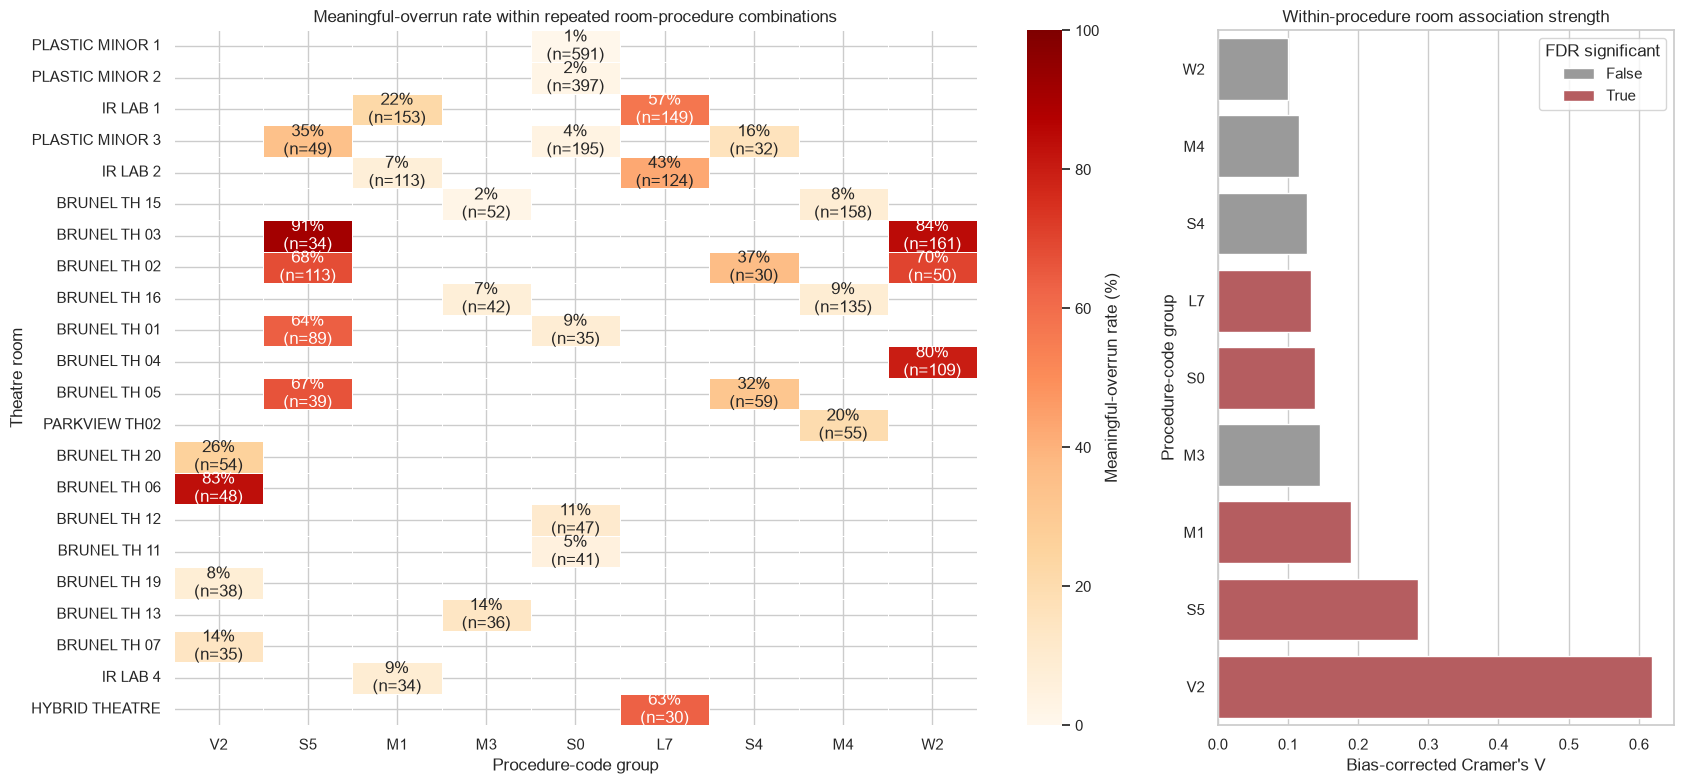

In [19]:
eligible_groups = room_procedure_interaction.sort_values(
    "cramers_v_corrected", ascending=False
)["procedure_code_group"]
eligible_combinations = interaction_rates[
    interaction_rates["procedure_code_group"].isin(eligible_groups)
].copy()
room_order = (
    eligible_combinations.groupby("TheatreRoom")["cases"]
    .sum().sort_values(ascending=False).index
)

rate_matrix = eligible_combinations.pivot(
    index="TheatreRoom", columns="procedure_code_group", values="overrun_rate"
).reindex(index=room_order, columns=eligible_groups) * 100
count_matrix = eligible_combinations.pivot(
    index="TheatreRoom", columns="procedure_code_group", values="cases"
).reindex(index=room_order, columns=eligible_groups)
annotations = rate_matrix.copy().astype(object)
for room in rate_matrix.index:
    for procedure in rate_matrix.columns:
        rate = rate_matrix.loc[room, procedure]
        count = count_matrix.loc[room, procedure]
        annotations.loc[room, procedure] = (
            f"{rate:.0f}%\n(n={count:.0f})" if pd.notna(rate) else ""
        )

fig, axes = plt.subplots(1, 2, figsize=(17, 8), gridspec_kw={"width_ratios": [2.2, 1]})
sns.heatmap(
    rate_matrix, annot=annotations, fmt="", cmap="OrRd", vmin=0, vmax=100,
    linewidths=.4, cbar_kws={"label": "Meaningful-overrun rate (%)"}, ax=axes[0]
)
axes[0].set(
    title="Meaningful-overrun rate within repeated room-procedure combinations",
    xlabel="Procedure-code group", ylabel="Theatre room"
)

effect_plot = room_procedure_interaction.sort_values("cramers_v_corrected")
sns.barplot(
    data=effect_plot, x="cramers_v_corrected", y="procedure_code_group",
    hue="reject_fdr_0_05", palette={True: "#C44E52", False: "#9A9A9A"},
    dodge=False, ax=axes[1]
)
axes[1].set(
    title="Within-procedure room association strength",
    xlabel="Bias-corrected Cramer's V", ylabel="Procedure-code group"
)
axes[1].legend(title="FDR significant")
plt.tight_layout()

**Interpretation.** Only nine broad procedure groups met the repetition rule, confirming that procedure allocation is highly specialised by room. Five groups showed evidence of room heterogeneity after false-discovery-rate correction, but not all signals were equally reliable or large.

`V2` had the strongest within-procedure room association (Cramer's V = 0.619; 175 cases across four rooms), with observed overrun rates ranging from 7.9% in BRUNEL TH 19 to 83.3% in BRUNEL TH 06. `S5` showed a moderate association (V = 0.285; 324 cases across five rooms), ranging from 34.7% in PLASTIC MINOR 3 to 91.2% in BRUNEL TH 03. `M1` showed a smaller association (V = 0.190; 300 cases across three IR rooms), with rates from 7.1% in IR LAB 2 to 22.2% in IR LAB 1. `L7` was weaker and borderline after correction (V = 0.133; adjusted `p = 0.046`). Although `S0` was statistically significant, its minimum expected cell count was below five, so its chi-square result is not considered dependable without category consolidation or an exact/Monte Carlo analysis. `W2`, despite high rates across its rooms, did not show clear evidence that those rates differed by room after correction.

This screening improves on overall room comparisons because it compares rooms within the same broad procedure group. It still does not identify a causal room effect: broad groups contain different specific procedures, and patient complexity, urgency, anaesthetic practice, specialty, staffing and booking calibration may differ within each cell. The result is a shortlist for validation and a future hierarchical model, not a room-performance ranking. The unrestricted room-by-procedure interaction is deliberately not fitted because structural zeros and sparse cells would produce unstable or non-identifiable coefficients.

## 9. Conclusions and decision rules

The statistical analysis should support conclusions only when four conditions align: an interpretable effect direction, a meaningful effect size, adequate precision, and acceptable data quality. Statistical significance by itself is insufficient.

The principal report should distinguish:

- **Unadjusted evidence:** rank and chi-square comparisons showing where distributions differ.
- **Adjusted evidence:** logistic-regression odds ratios showing which preoperative factors remain associated with meaningful overrun after simultaneous adjustment.
- **Agreement evidence:** paired differences and Bland-Altman limits showing whether booked duration is sufficiently accurate at case level.
- **Data-quality evidence:** missingness and sparse-category diagnostics showing where results are less dependable.

The current analysis cannot establish causation, measure true room utilisation, rank individual consultants, or validate reconstructed theatre-flow stages. These require validated staff identifiers, staffed session capacity, cancellations and downtime, plus confirmation of timestamp semantics from NBT.

## References

Benjamini, Y. and Hochberg, Y. (1995) 'Controlling the false discovery rate: a practical and powerful approach to multiple testing', *Journal of the Royal Statistical Society: Series B (Methodological)*, 57(1), pp. 289-300. doi: 10.1111/j.2517-6161.1995.tb02031.x.

Bland, J.M. and Altman, D.G. (1986) 'Statistical methods for assessing agreement between two methods of clinical measurement', *The Lancet*, 327(8476), pp. 307-310. doi: 10.1016/S0140-6736(86)90837-8.

Conover, W.J. (1999) *Practical nonparametric statistics*. 3rd edn. New York: John Wiley & Sons.

Fritz, C.O., Morris, P.E. and Richler, J.J. (2012) 'Effect size estimates: current use, calculations, and interpretation', *Journal of Experimental Psychology: General*, 141(1), pp. 2-18. doi: 10.1037/a0024338.

Hosmer, D.W., Lemeshow, S. and Sturdivant, R.X. (2013) *Applied logistic regression*. 3rd edn. Hoboken, NJ: John Wiley & Sons. doi: 10.1002/9781118548387.

Kruskal, W.H. and Wallis, W.A. (1952) 'Use of ranks in one-criterion variance analysis', *Journal of the American Statistical Association*, 47(260), pp. 583-621. doi: 10.1080/01621459.1952.10483441.

Mann, H.B. and Whitney, D.R. (1947) 'On a test of whether one of two random variables is stochastically larger than the other', *The Annals of Mathematical Statistics*, 18(1), pp. 50-60. doi: 10.1214/aoms/1177730491.

Spearman, C. (1904) 'The proof and measurement of association between two things', *The American Journal of Psychology*, 15(1), pp. 72-101. doi: 10.2307/1412159.

von Elm, E., Altman, D.G., Egger, M., Pocock, S.J., Gotzsche, P.C. and Vandenbroucke, J.P. (2007) 'The Strengthening the Reporting of Observational Studies in Epidemiology (STROBE) statement: guidelines for reporting observational studies', *The Lancet*, 370(9596), pp. 1453-1457. doi: 10.1016/S0140-6736(07)61602-X.

Wilcoxon, F. (1945) 'Individual comparisons by ranking methods', *Biometrics Bulletin*, 1(6), pp. 80-83. doi: 10.2307/3001968.